In [13]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# For Excel file reading
!pip install openpyxl  # if not already installed (optional)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [14]:
# Load the Excel file
file_path = "../Data/Raw/telecom_customer_segmentation.xlsx"
df = pd.read_excel(file_path, engine='openpyxl')

# Display first few rows to verify loading
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customer_id,age,gender,region,plan_type,tenure_months,monthly_revenue_usd,total_call_minutes,data_usage_gb,sms_count,intl_call_minutes,roaming_enabled,logins_per_month,support_tickets_6mo,days_since_last_call,num_services_subscribed,auto_pay_enrolled,paperless_billing,contract_type,true_segment
0,CUST00001,51,Female,East,Premium,54,47.52,302.2,2.83,97,6,0,13,0,43,4,1,1,2-Year,Moderate User
1,CUST00002,59,Female,North,Basic,15,39.73,127.6,2.44,68,5,0,5,2,46,1,0,1,Month-to-Month,Churner
2,CUST00003,67,Female,South,Standard,3,24.09,76.3,1.76,10,1,0,8,0,43,2,0,1,1-Year,Low User
3,CUST00004,55,Female,West,Basic,17,26.43,12.4,2.19,40,2,0,1,0,42,3,0,0,2-Year,Low User
4,CUST00005,19,Female,North,Unlimited,25,118.19,955.0,30.06,320,19,0,24,2,51,5,0,0,2-Year,Heavy User


In [15]:
# Dataset shape (rows, columns)
print(f"Dataset shape: {df.shape}\n")

# Column names and data types
print("Data types and non-null counts:")
print(df.info())

# Summary statistics for numerical columns
print("\nSummary statistics for numerical features:")
df.describe()

Dataset shape: (5000, 20)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   str    
 1   age                      5000 non-null   int64  
 2   gender                   5000 non-null   str    
 3   region                   5000 non-null   str    
 4   plan_type                5000 non-null   str    
 5   tenure_months            5000 non-null   int64  
 6   monthly_revenue_usd      5000 non-null   float64
 7   total_call_minutes       5000 non-null   float64
 8   data_usage_gb            5000 non-null   float64
 9   sms_count                5000 non-null   int64  
 10  intl_call_minutes        5000 non-null   int64  
 11  roaming_enabled          5000 non-null   int64  
 12  logins_per_month         5000 non-null   int64  
 13  support_tickets_6mo      5000 

,age,tenure_months,monthly_revenue_usd,total_call_minutes,data_usage_gb,sms_count,intl_call_minutes,roaming_enabled,logins_per_month,support_tickets_6mo,days_since_last_call,num_services_subscribed,auto_pay_enrolled,paperless_billing
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,46.374600,39.862200,63.856186,383.448440,11.550558,152.190800,18.00320,0.414800,13.993200,0.965000,29.604800,2.999200,0.657800,0.701600
std,16.362549,32.615867,58.815021,280.521772,8.966718,133.170668,22.01488,0.492737,8.325612,1.468947,17.370244,1.412515,0.474494,0.457602
min,18.000000,1.000000,10.020000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,33.000000,14.000000,27.477500,127.500000,3.260000,41.000000,3.00000,0.000000,6.000000,0.000000,14.000000,2.000000,0.000000,0.000000
50%,47.000000,31.000000,44.400000,337.000000,9.630000,115.000000,9.00000,0.000000,14.000000,0.000000,30.000000,3.000000,1.000000,1.000000
75%,61.000000,56.000000,77.545000,583.550000,18.580000,222.250000,22.00000,1.000000,20.250000,1.000000,44.000000,4.000000,1.000000,1.000000
max,74.000000,143.000000,299.800000,1280.300000,39.380000,499.000000,99.00000,1.000000,29.000000,7.000000,59.000000,5.000000,1.000000,1.000000


In [16]:
# Count missing values per column
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])
# If no missing values, the output will be empty.

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Segment distribution:
true_segment
Moderate User    1719
Low User         1253
Heavy User       1029
High Revenue      520
Churner           479
Name: count, dtype: int64

Percentage distribution:
true_segment
Moderate User    34.38
Low User         25.06
Heavy User       20.58
High Revenue     10.40
Churner           9.58
Name: proportion, dtype: float64


C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1397722967.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='true_segment', order=df['true_segment'].value_counts().index, palette='viridis')


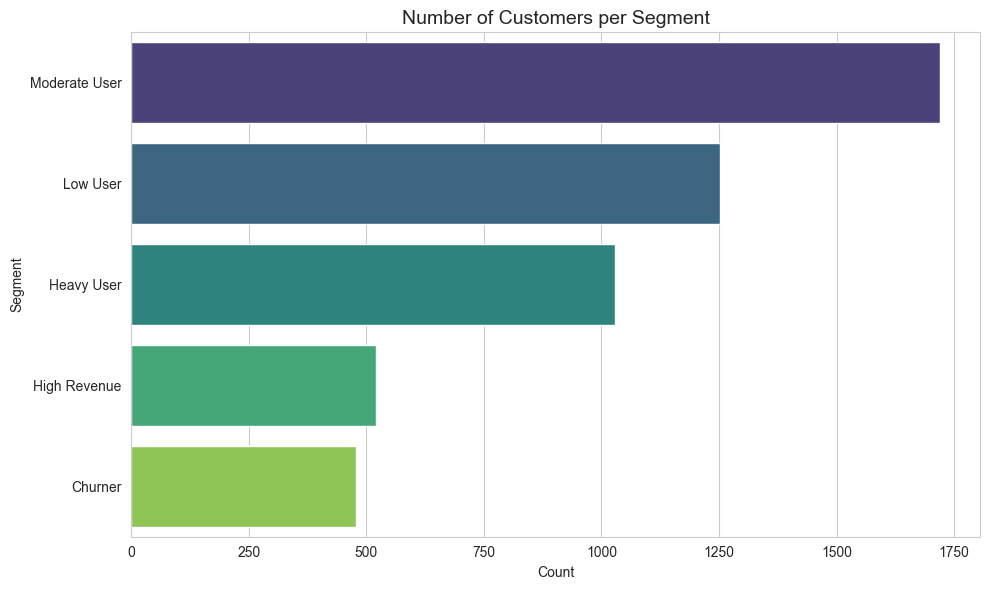

In [17]:
# Distribution of customer segments
print("Segment distribution:")
print(df['true_segment'].value_counts())
print("\nPercentage distribution:")
print(df['true_segment'].value_counts(normalize=True) * 100)

# Bar plot
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='true_segment', order=df['true_segment'].value_counts().index, palette='viridis')
plt.title('Number of Customers per Segment', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

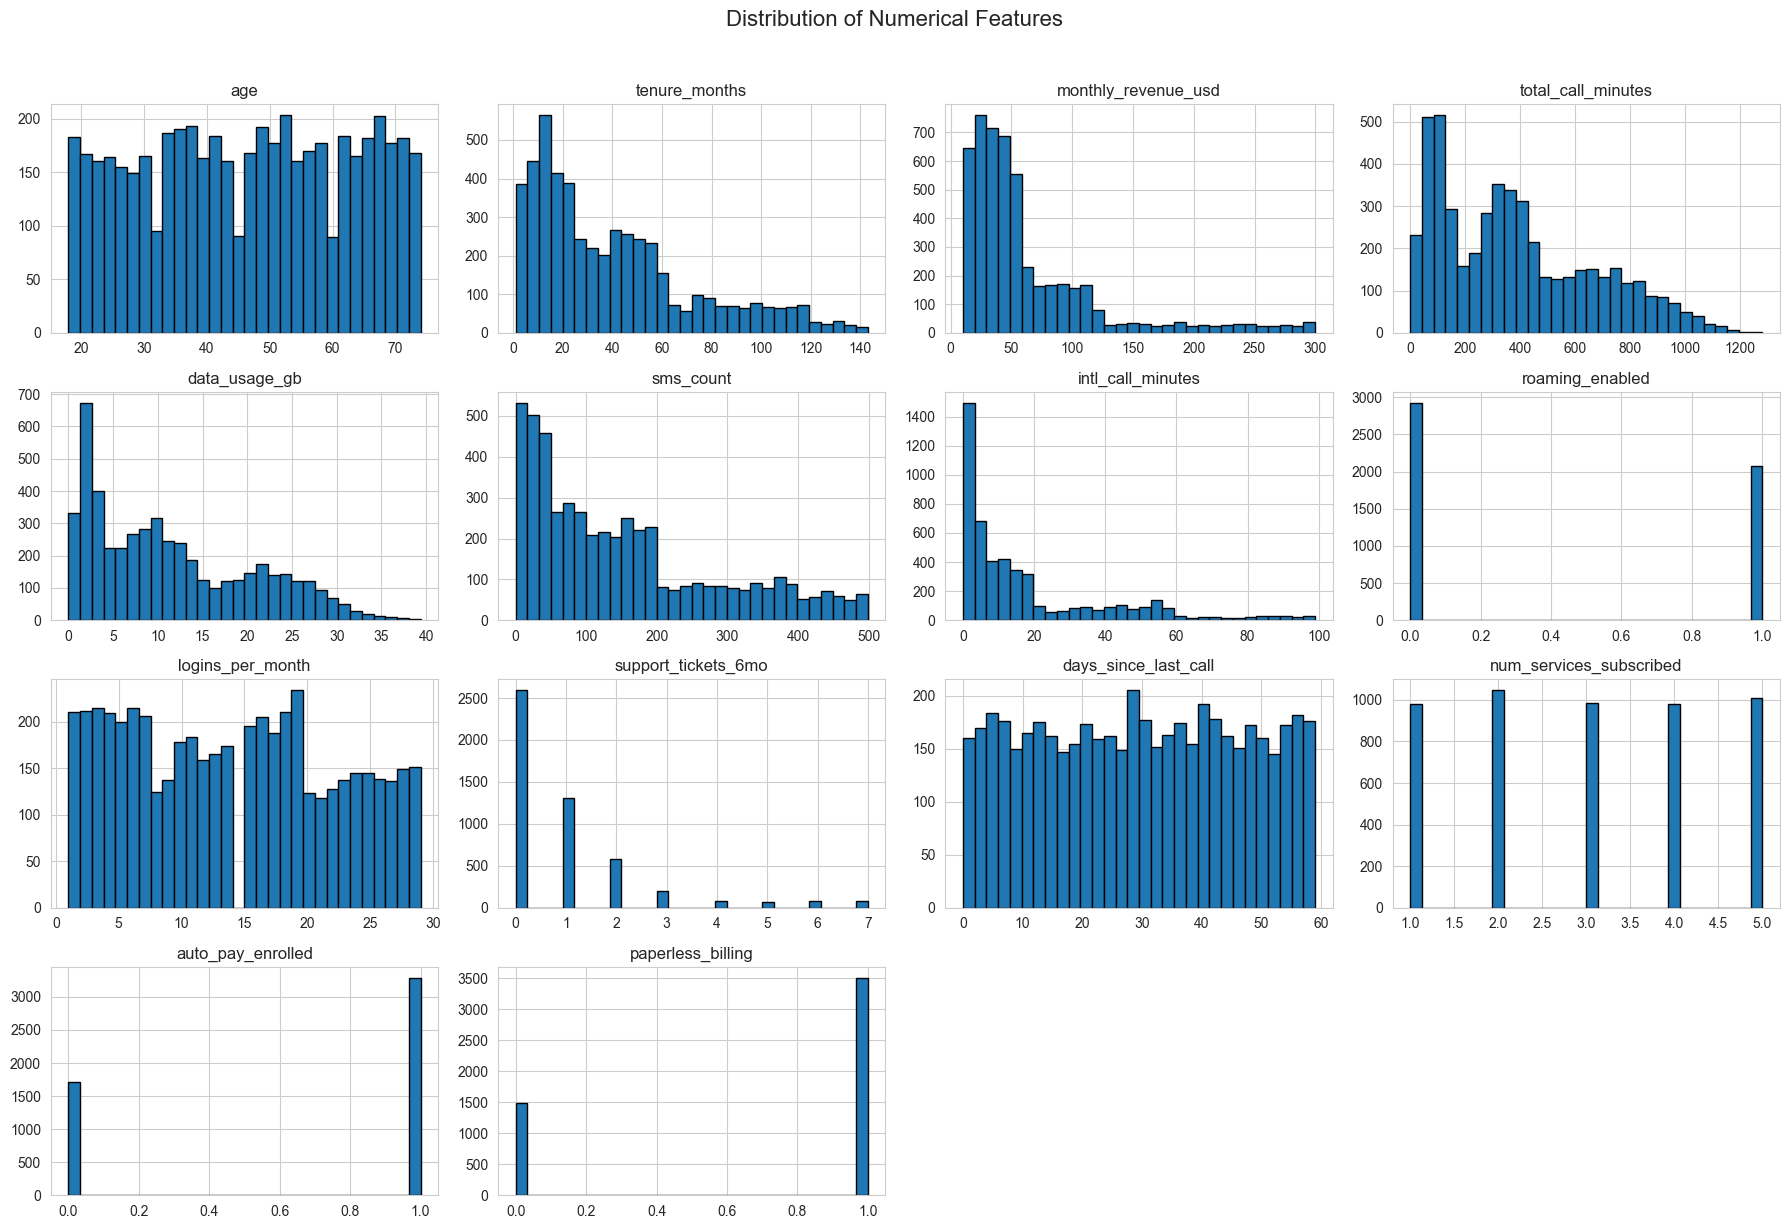

In [18]:
# Select numerical columns (exclude identifier and target)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove 'customer_id' if present
numerical_cols = [col for col in numerical_cols if col != 'customer_id']

# Plot histograms
df[numerical_cols].hist(bins=30, figsize=(18, 12), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

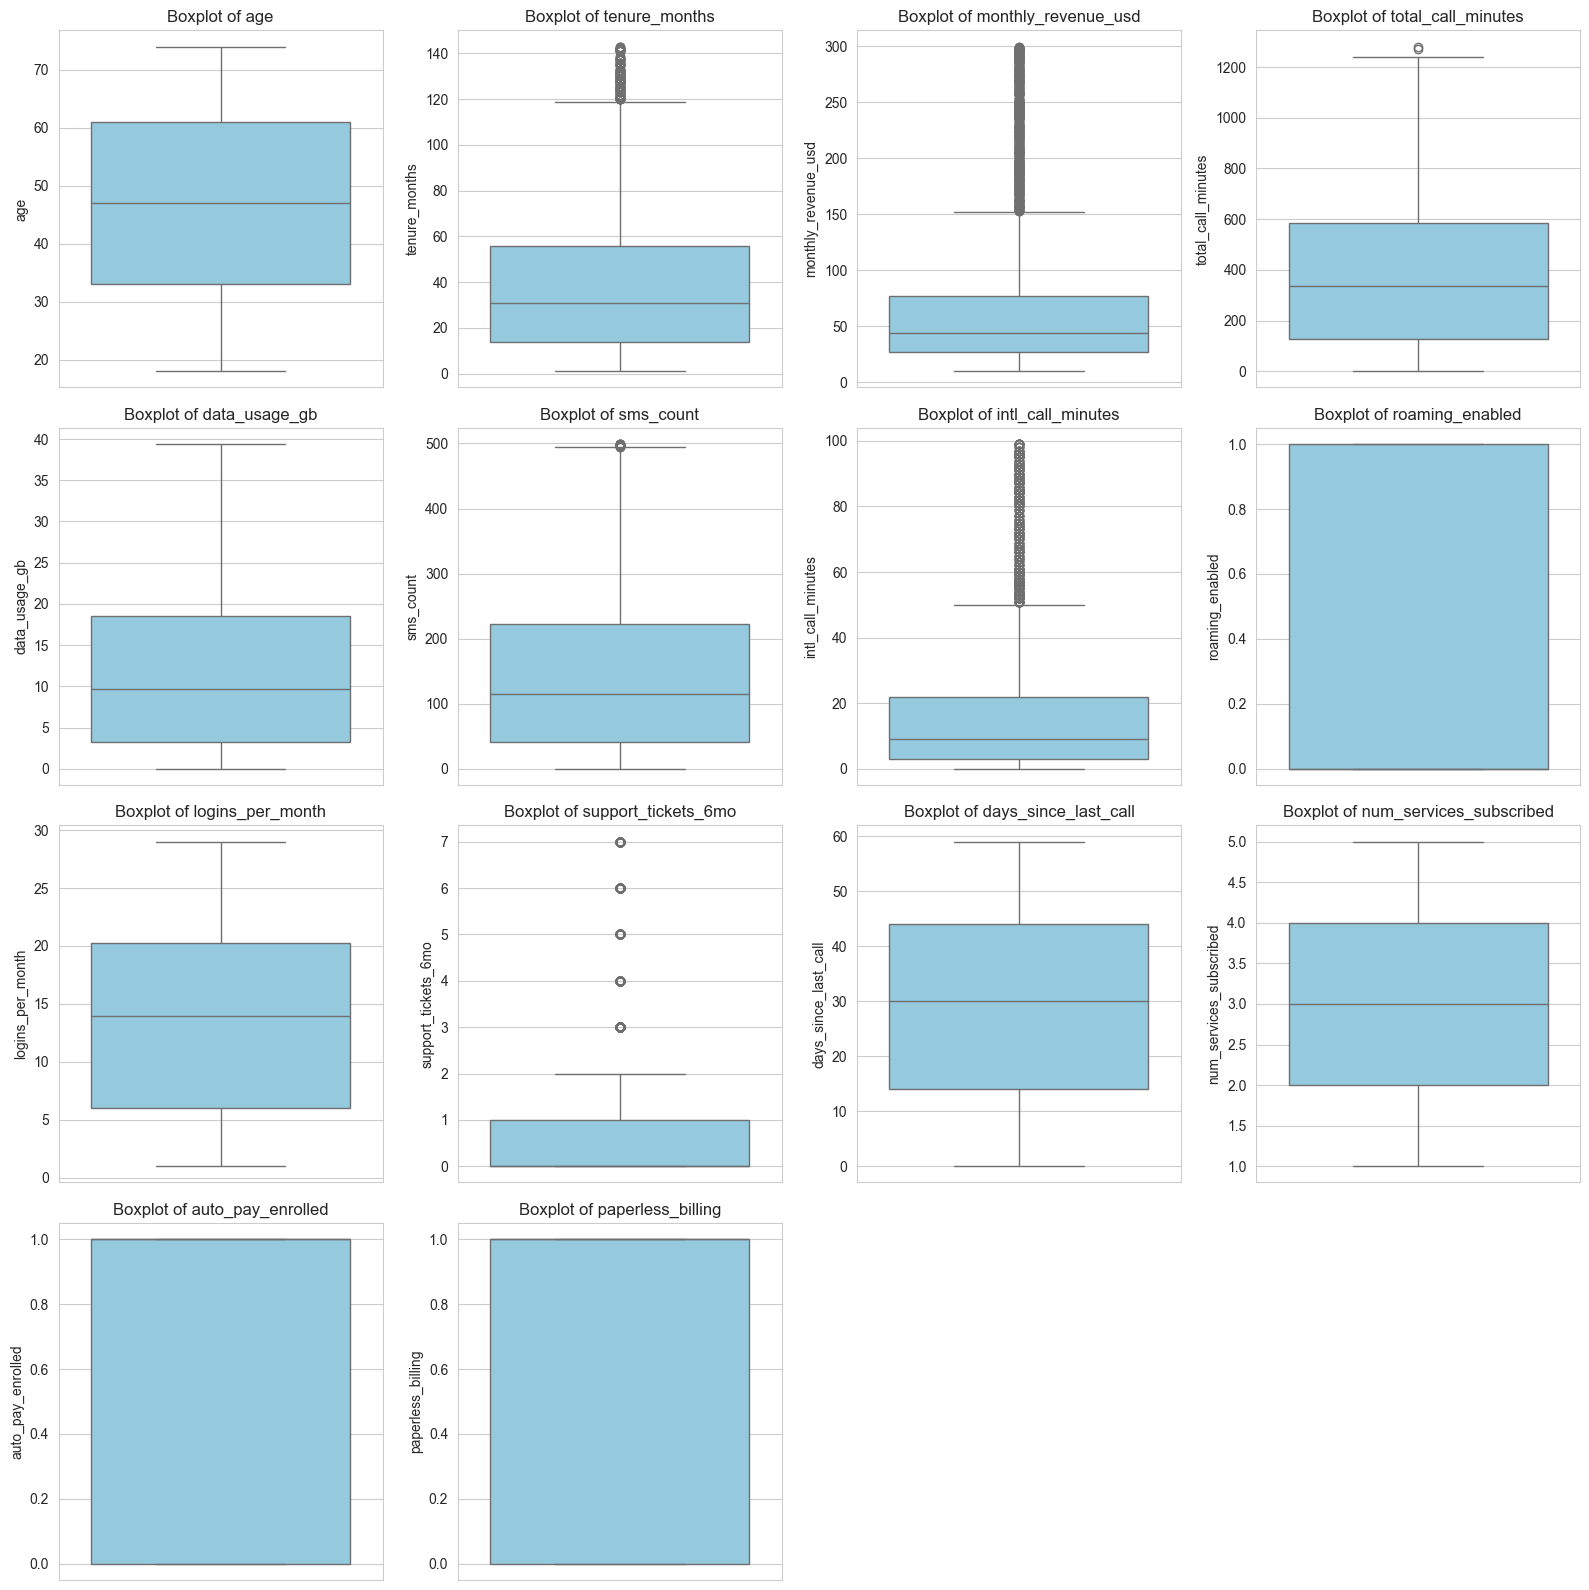

In [19]:
import math

# Number of numerical features
n_cols = len(numerical_cols)

# Determine grid size (e.g., 3 columns, rows = ceil(n_cols / 3))
n_cols_grid = 4  # number of columns in subplot grid
n_rows_grid = math.ceil(n_cols / n_cols_grid)

# Create subplots
plt.figure(figsize=(16, 4 * n_rows_grid))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows_grid, n_cols_grid, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

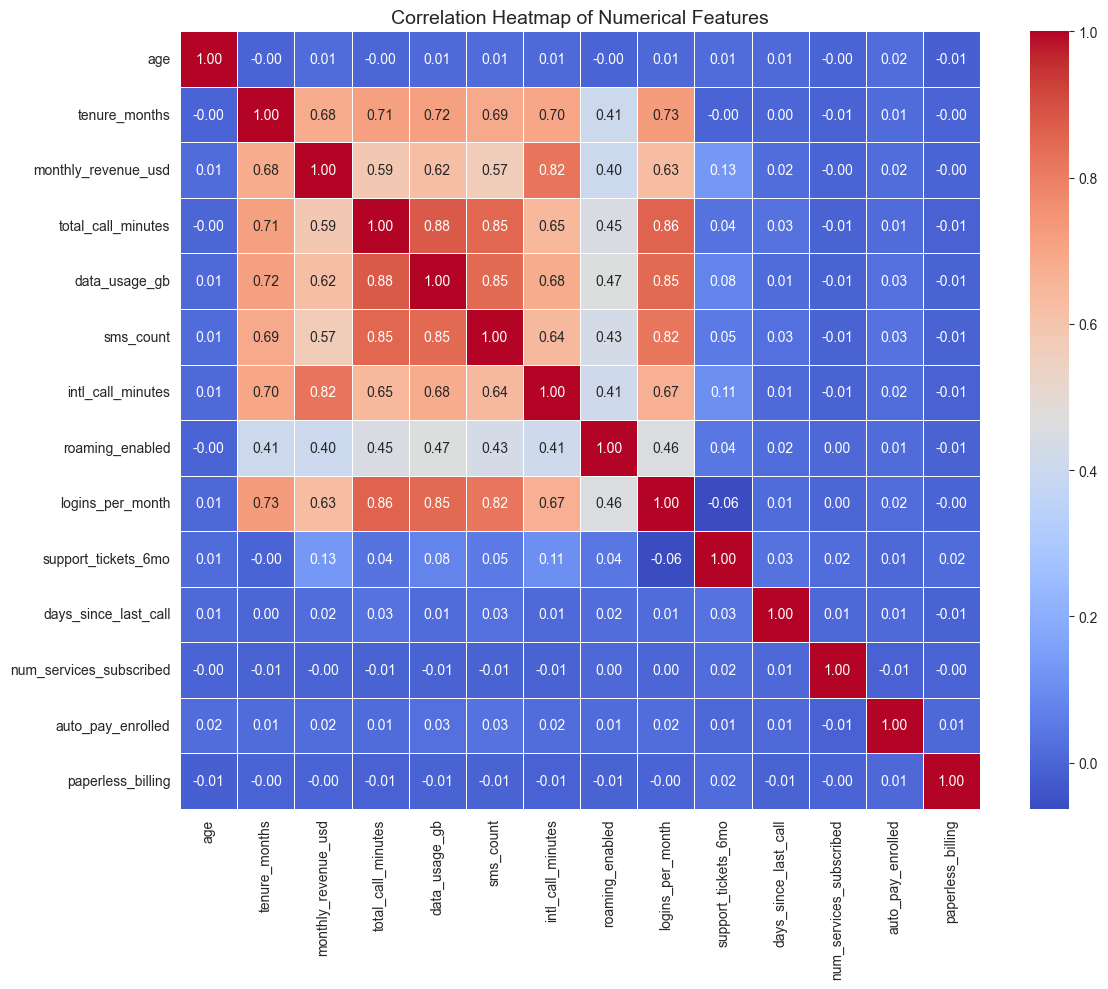

In [20]:
# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

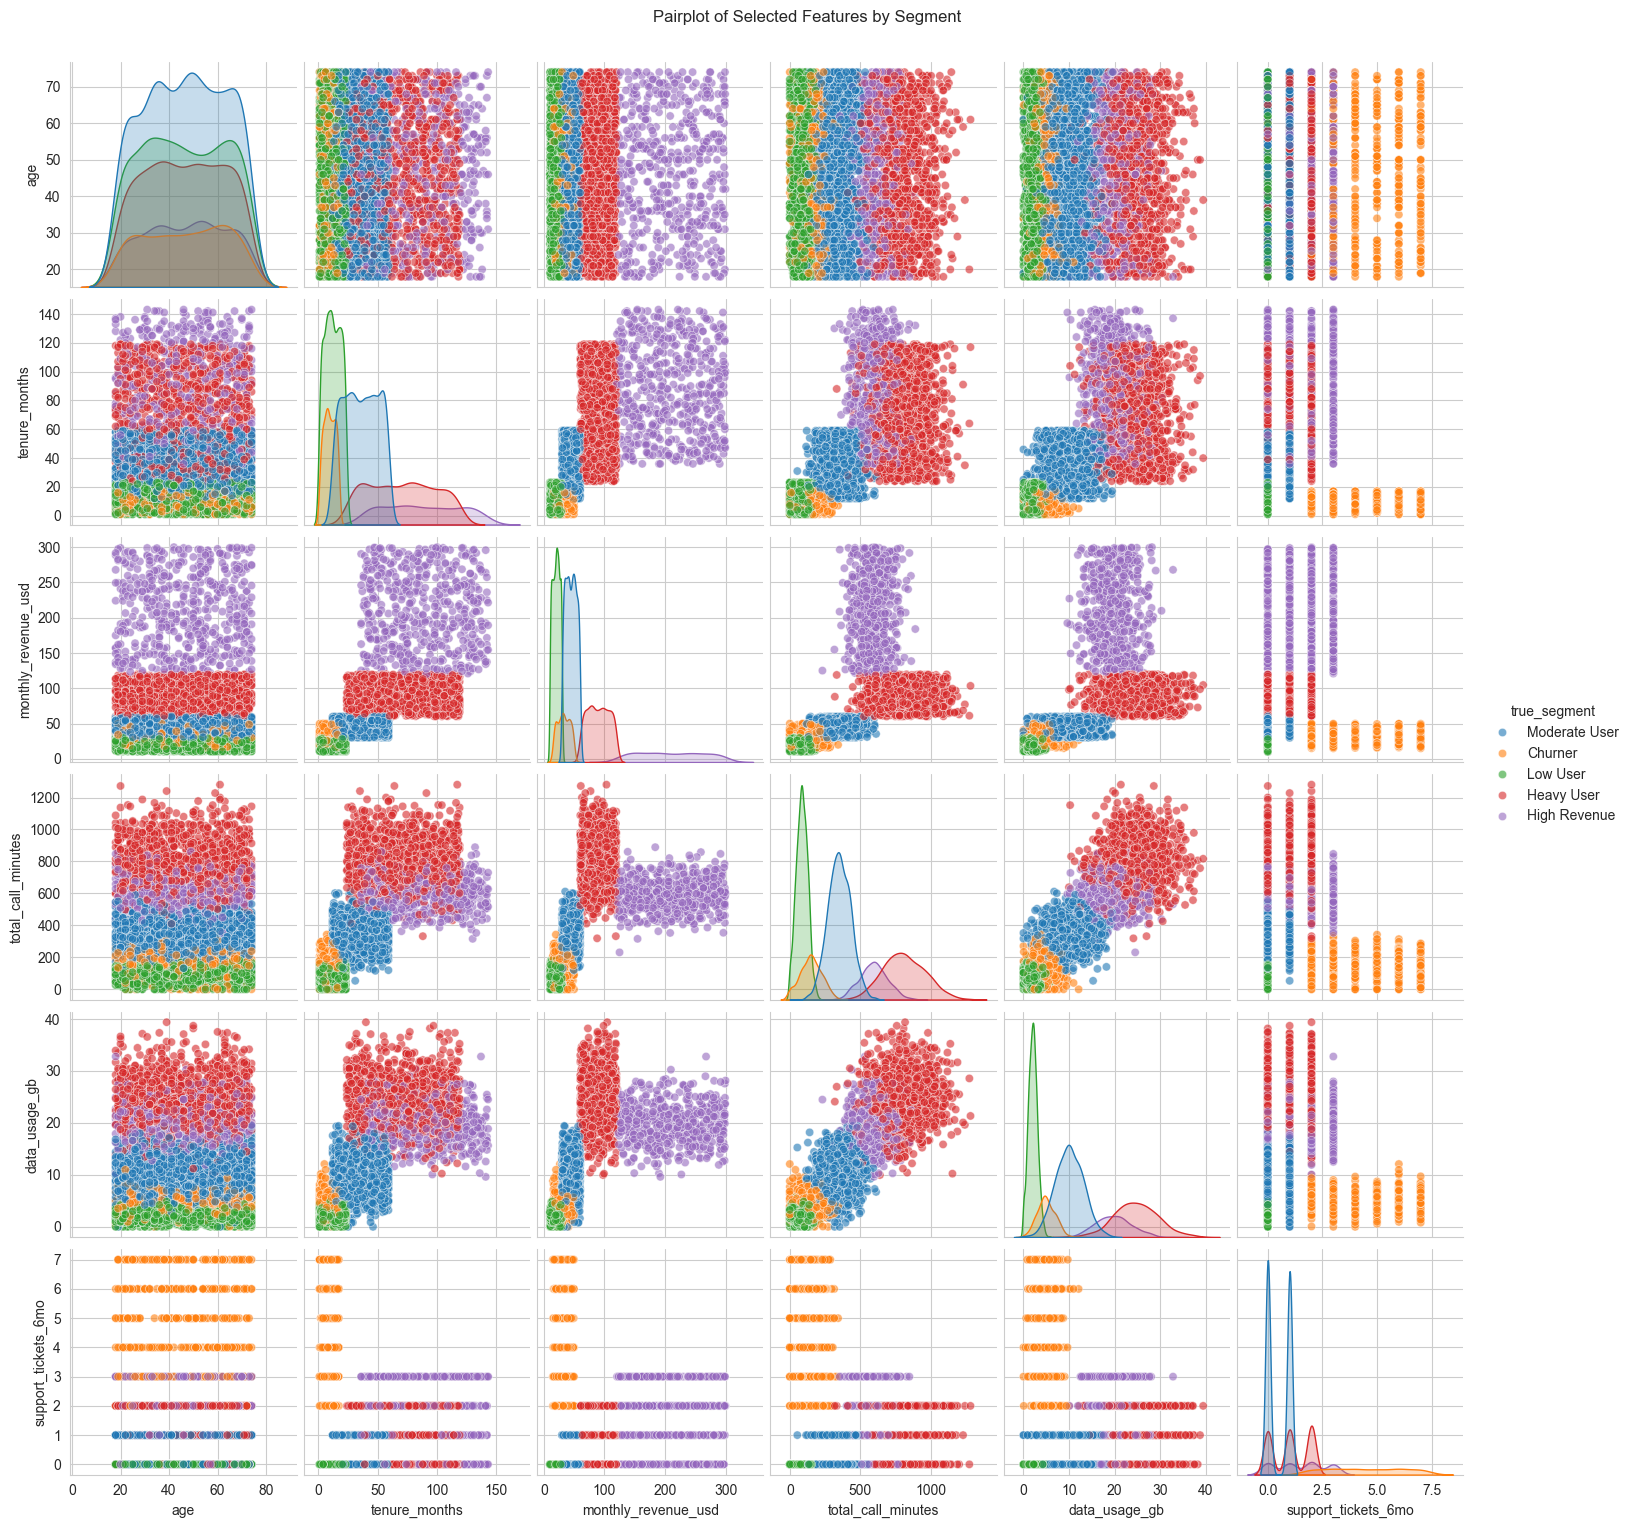

In [21]:
# Choose a subset of interesting features to avoid clutter
selected_features = ['age', 'tenure_months', 'monthly_revenue_usd',
                     'total_call_minutes', 'data_usage_gb', 'support_tickets_6mo']

# Pairplot colored by target segment
sns.pairplot(df[selected_features + ['true_segment']], hue='true_segment', diag_kind='kde',
             plot_kws={'alpha':0.6}, height=2.5)
plt.suptitle('Pairplot of Selected Features by Segment', y=1.02)
plt.show()

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1814580235.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1814580235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


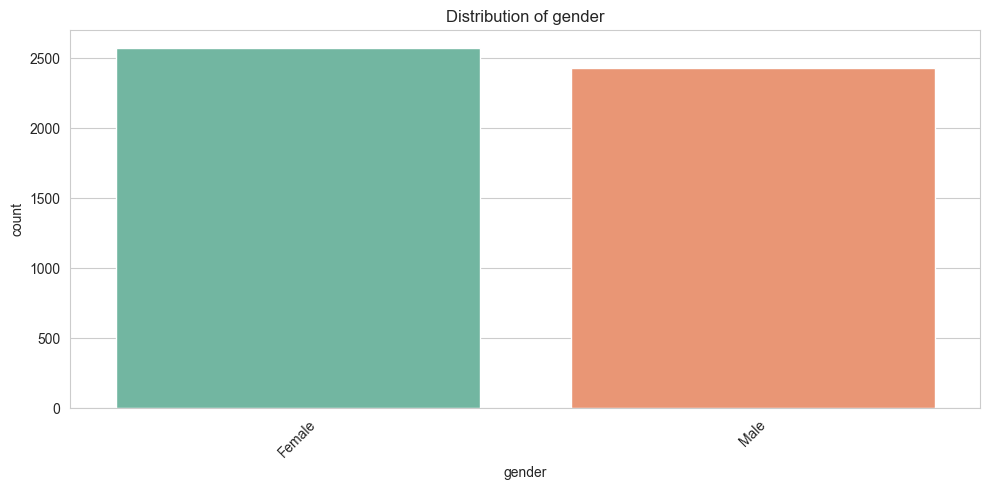

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1814580235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


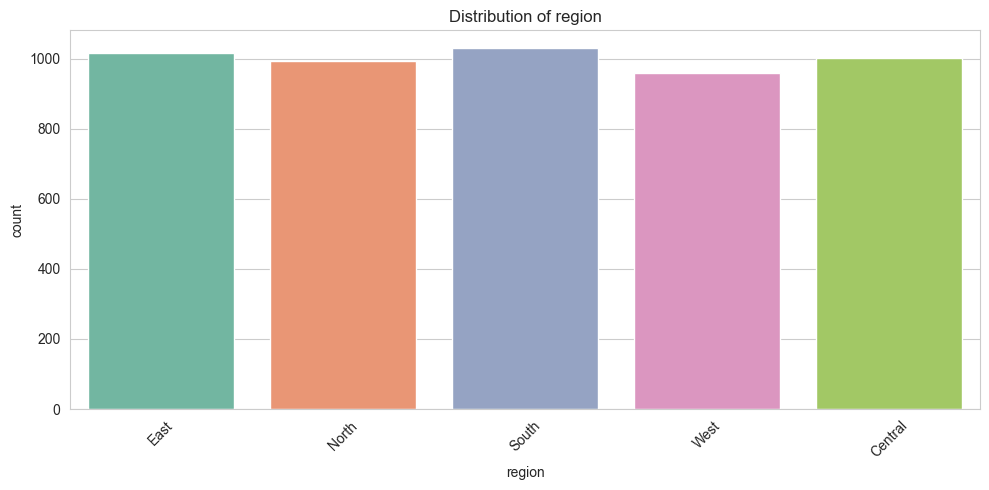

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1814580235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


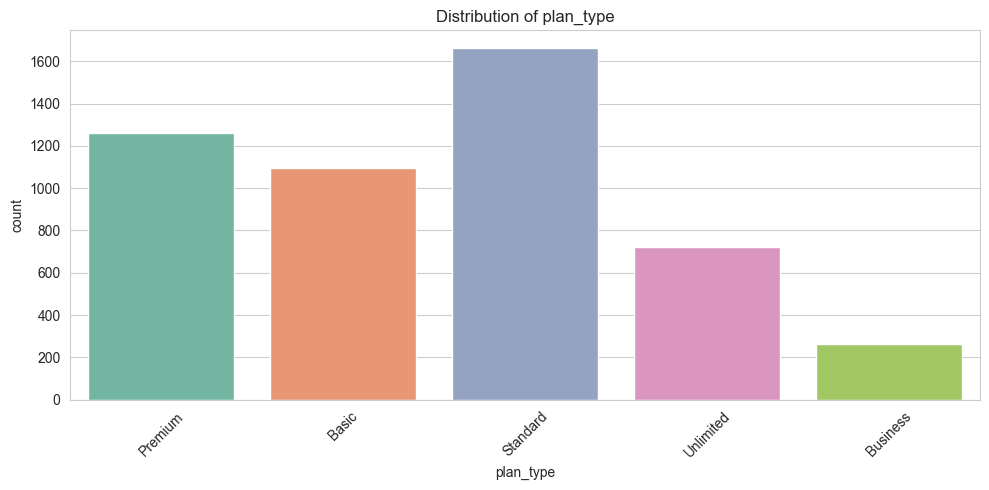

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\1814580235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


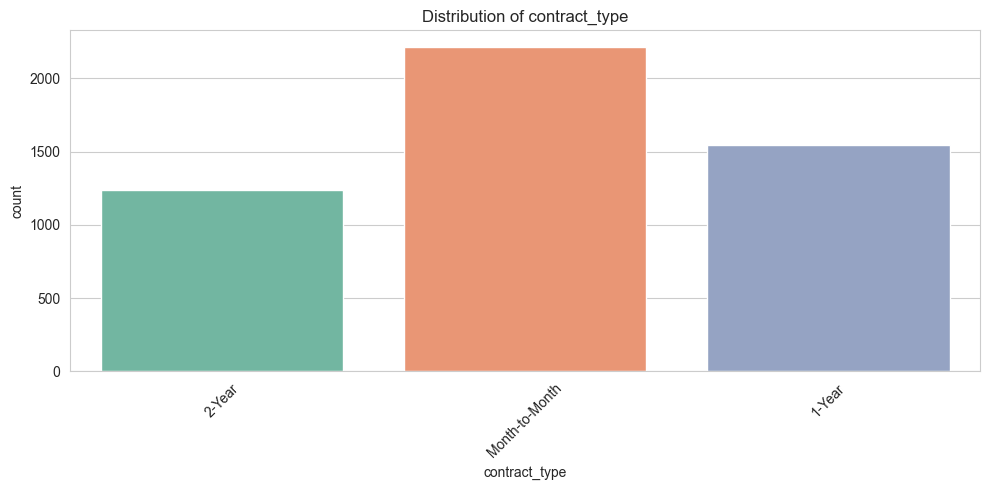


--- gender vs true_segment ---
true_segment    Churner  Heavy User  High Revenue   Low User  Moderate User
gender                                                                     
Female         9.147528   21.097703     10.704554  24.834566      34.215648
Male          10.037022   20.032908     10.078157  25.298231      34.553682

--- region vs true_segment ---
true_segment    Churner  Heavy User  High Revenue   Low User  Moderate User
region                                                                     
Central        9.371884   19.840479     10.269192  25.523430      34.995015
East           9.153543   20.669291      8.464567  26.476378      35.236220
North         10.282258   20.060484     10.786290  23.185484      35.685484
South          9.232264   21.282799     11.370262  25.267250      32.847425
West           9.895833   21.041667     11.145833  24.791667      33.125000

--- plan_type vs true_segment ---
true_segment    Churner  Heavy User  High Revenue   Low User  Mod

In [22]:
# List of categorical columns (object or category type)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Remove 'customer_id' and 'true_segment' for now
categorical_cols = [col for col in categorical_cols if col not in ['customer_id', 'true_segment']]

# Plot count plots for each categorical feature
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Additionally, crosstabs with the target segment
for col in categorical_cols:
    print(f"\n--- {col} vs true_segment ---")
    print(pd.crosstab(df[col], df['true_segment'], normalize='index') * 100)

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


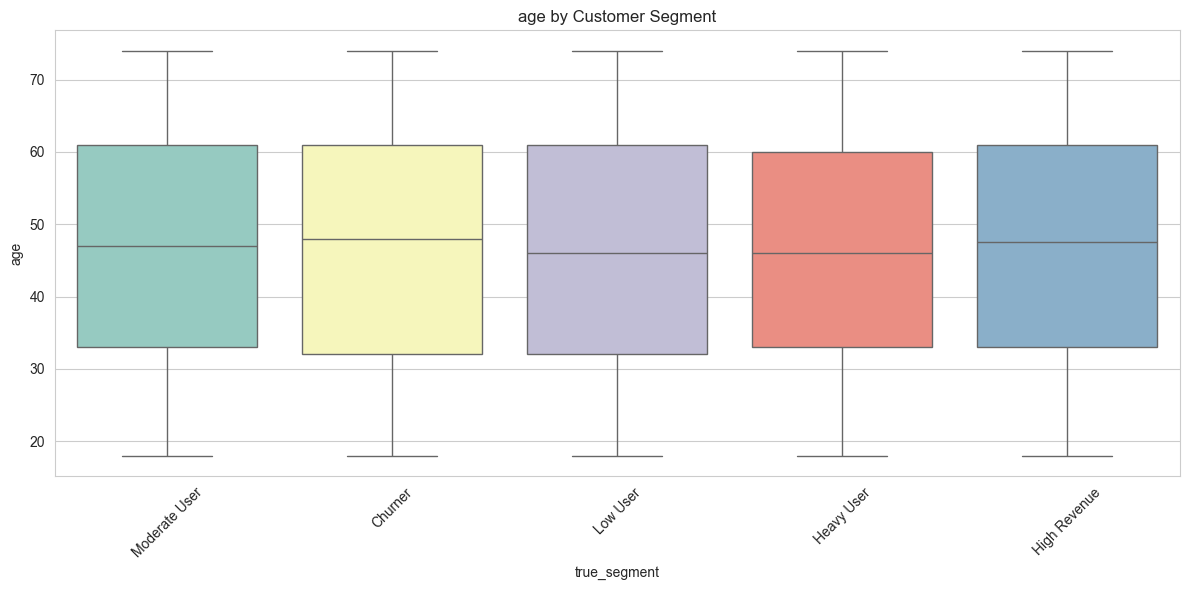

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


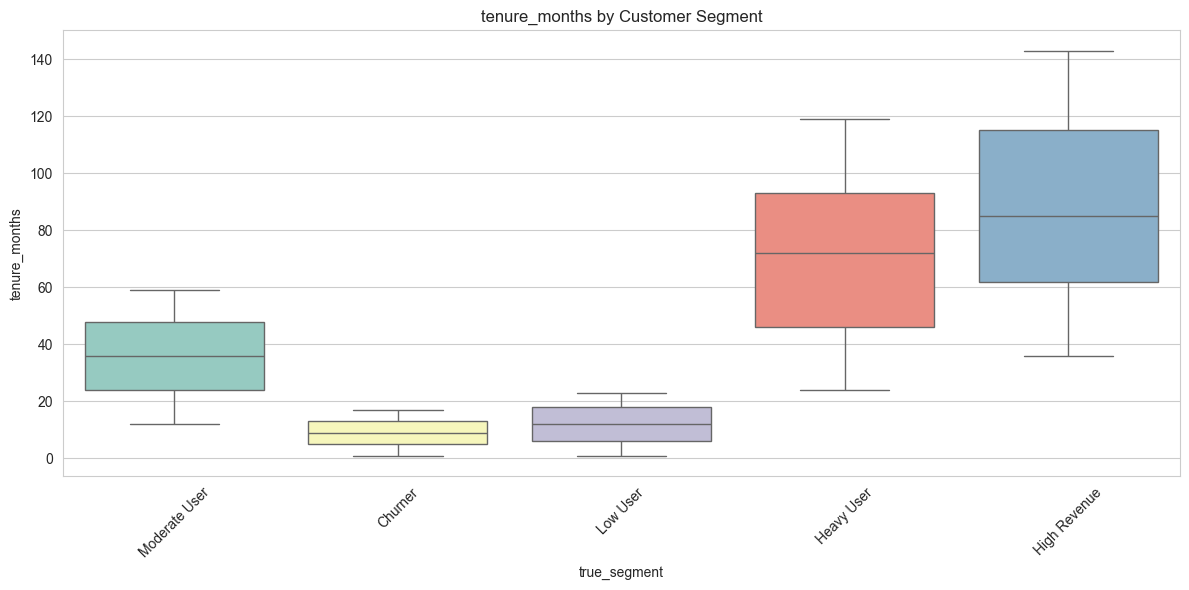

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


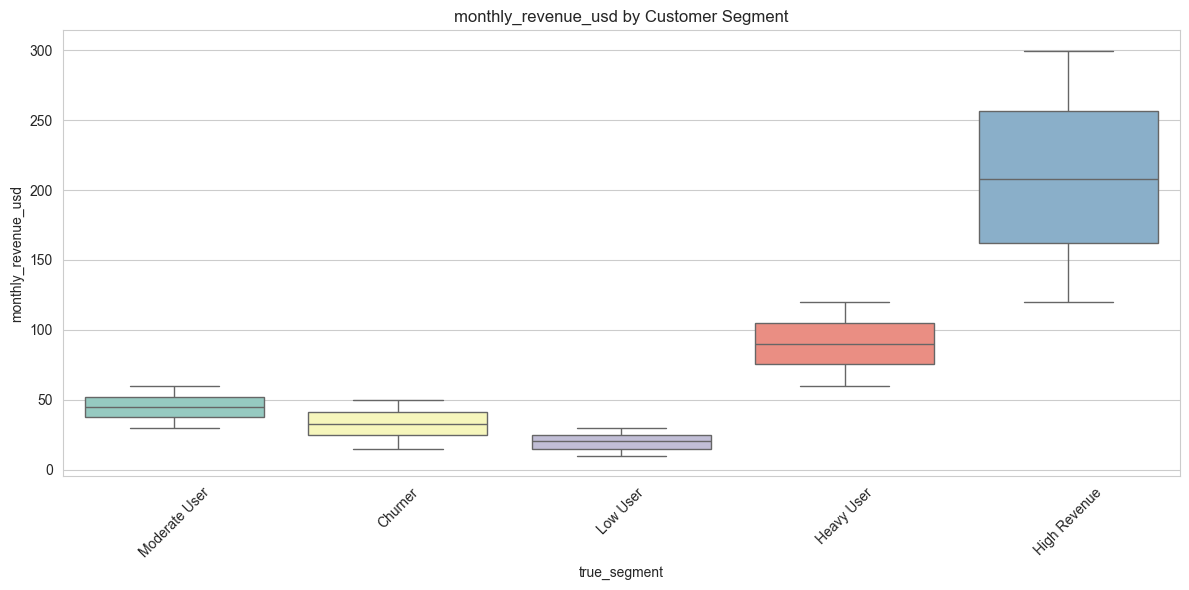

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


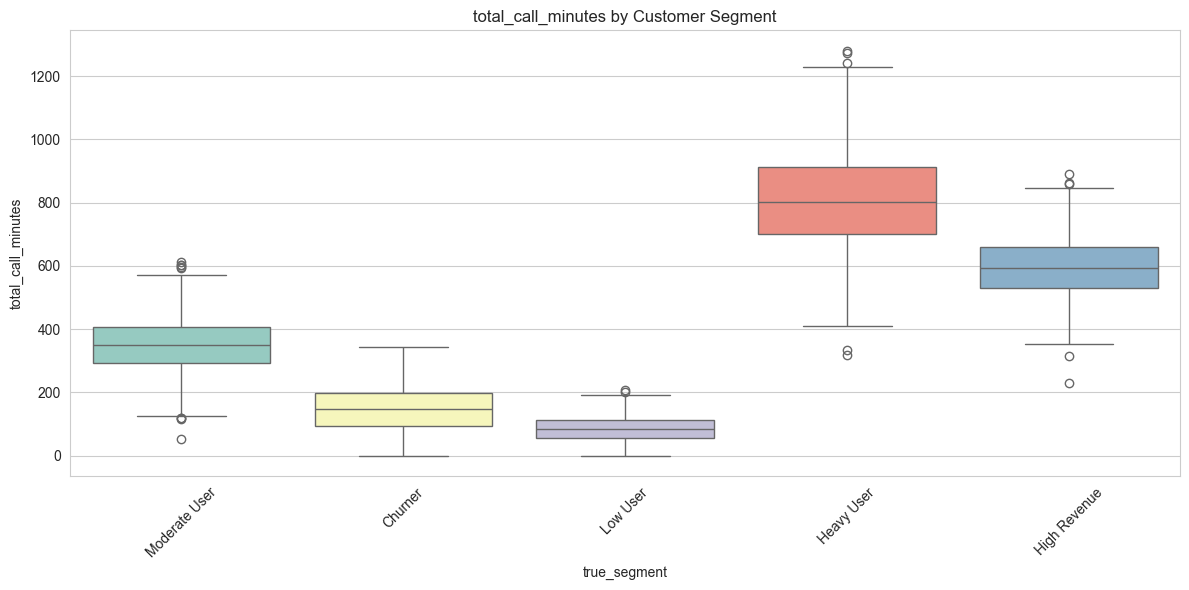

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


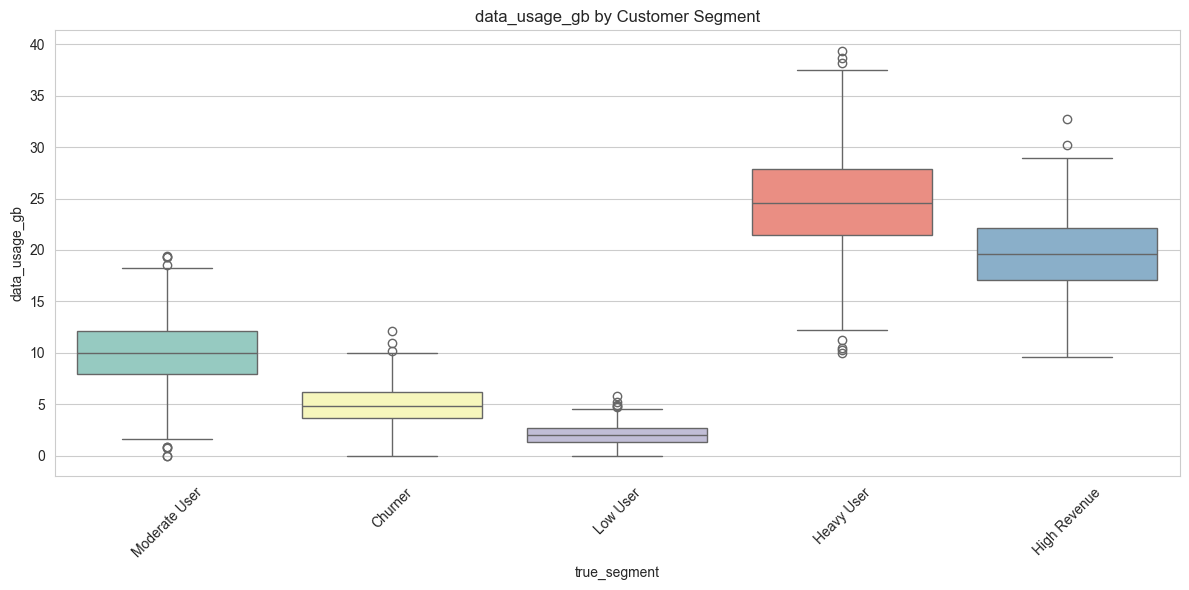

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


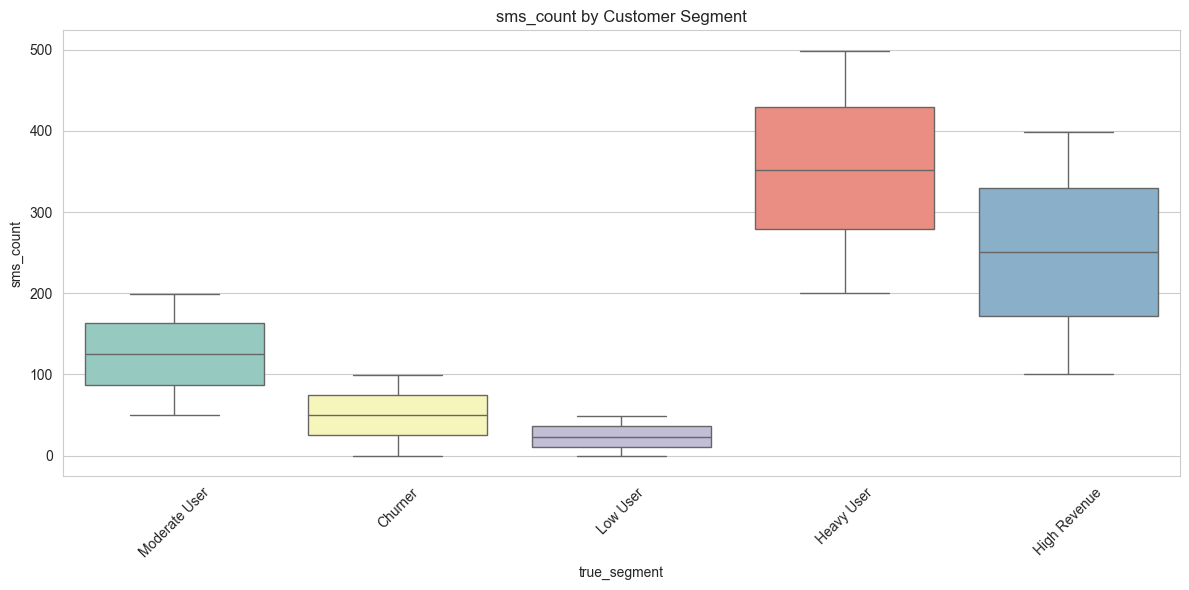

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


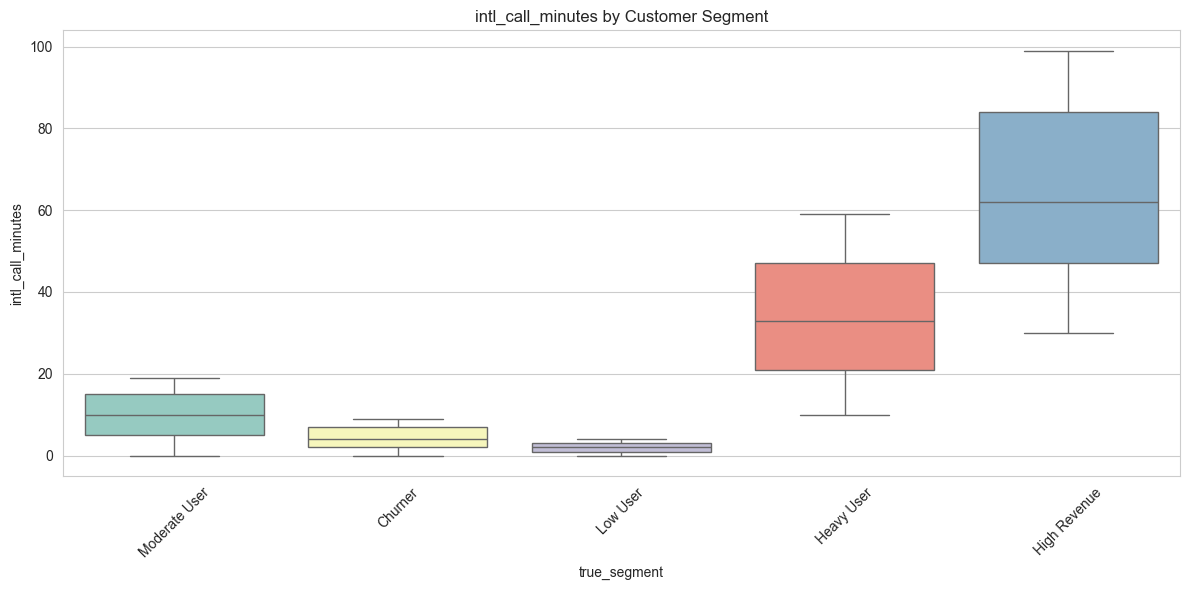

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


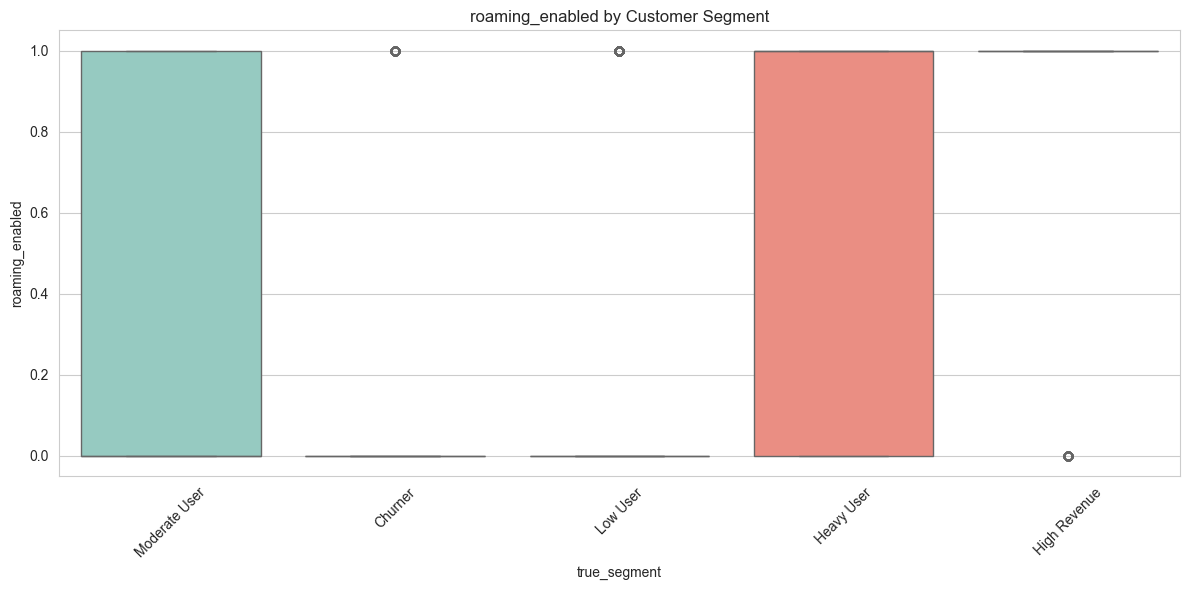

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


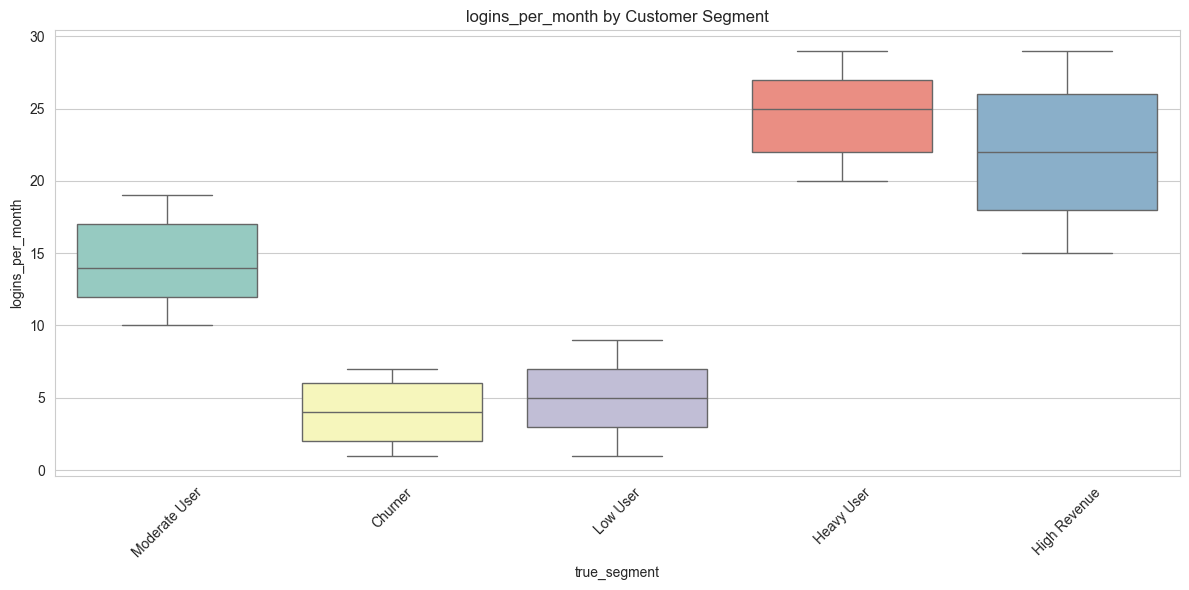

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


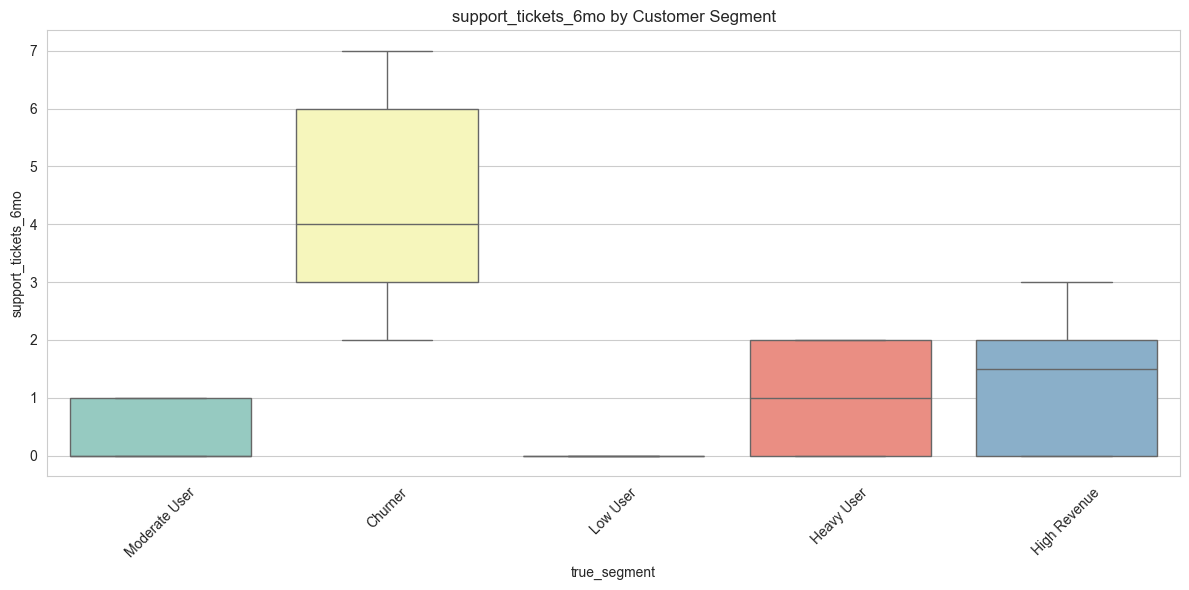

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


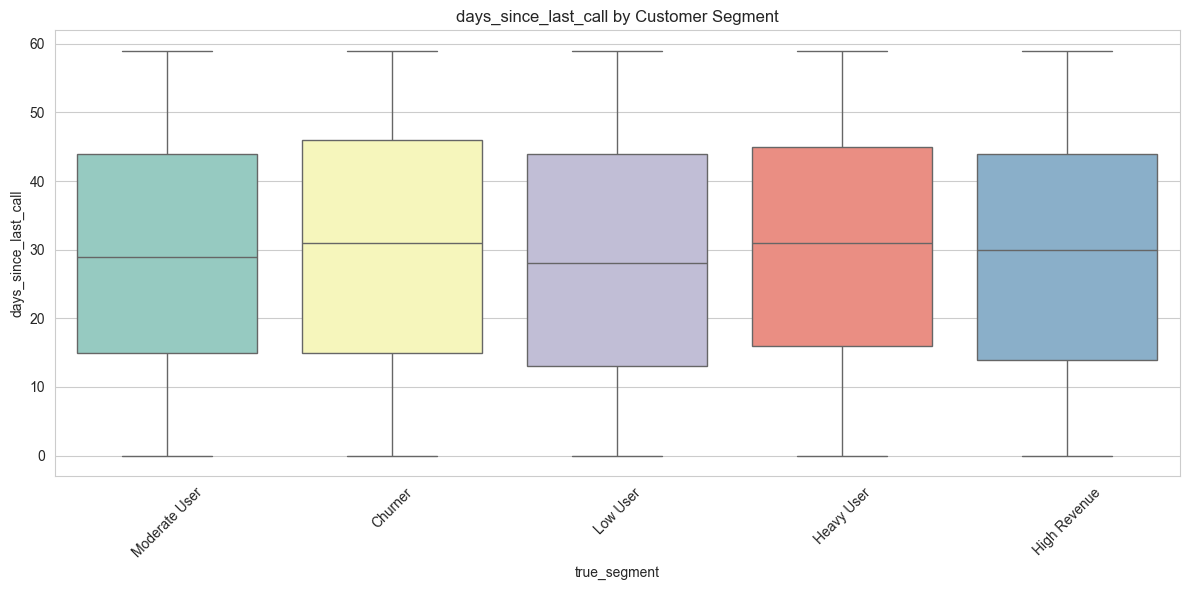

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


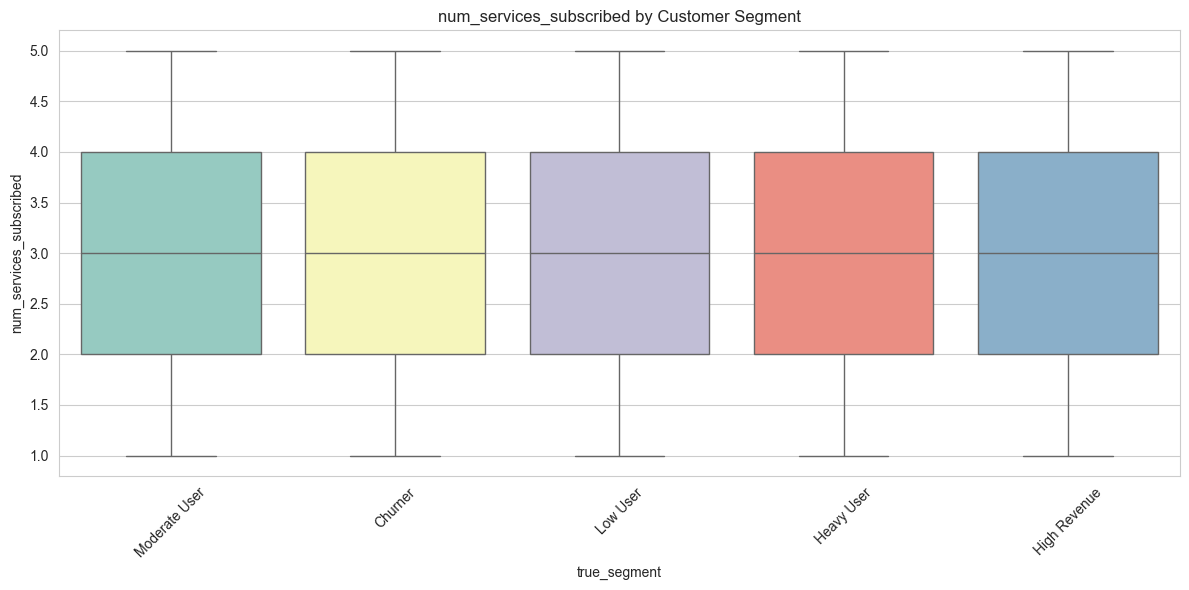

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


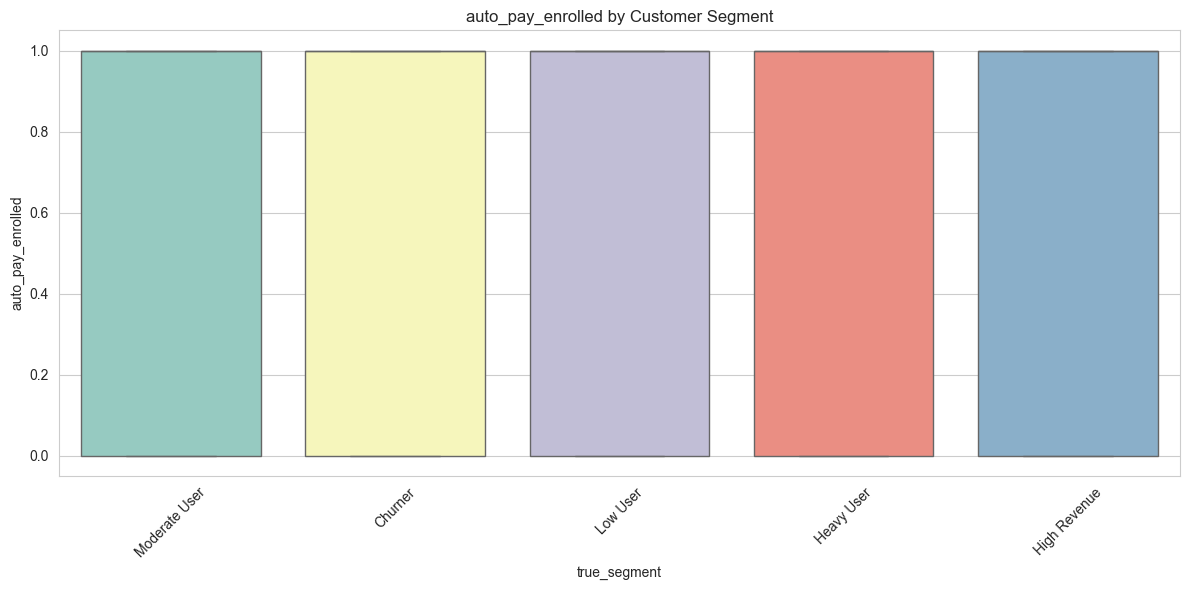

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_32220\2439460970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')


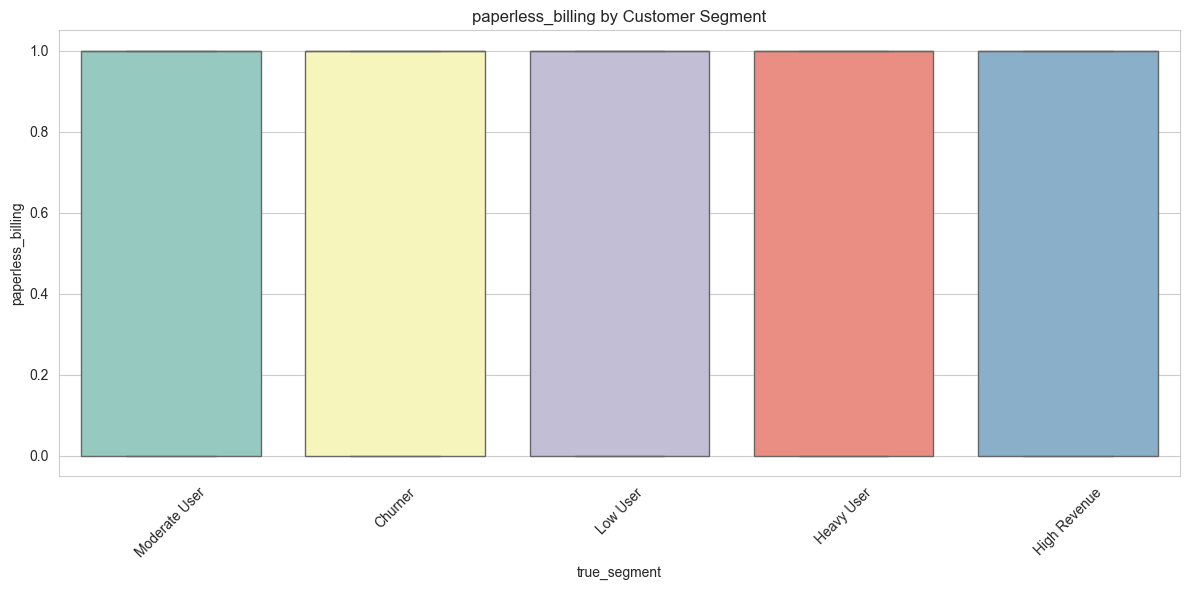

In [23]:
# For each numerical feature, create a boxplot grouped by 'true_segment'
for col in numerical_cols:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df, x='true_segment', y=col, palette='Set3')
    plt.title(f'{col} by Customer Segment')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
# Example: Print some key observations
print("===== EDA Summary =====")
print(f"Total records: {len(df)}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Missing values: {df.isnull().sum().sum()} (none if 0)")

print("\nTop 3 most correlated pairs (absolute):")
corr_abs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_abs = corr_abs[corr_abs < 1]  # remove self-correlation
print(corr_abs.head(3))

print("\nSegments with highest average monthly revenue:")
print(df.groupby('true_segment')['monthly_revenue_usd'].mean().sort_values(ascending=False))

===== EDA Summary =====
Total records: 5000
Numerical features: 14
Categorical features: 4
Missing values: 0 (none if 0)

Top 3 most correlated pairs (absolute):
data_usage_gb       total_call_minutes    0.878607
total_call_minutes  data_usage_gb         0.878607
logins_per_month    total_call_minutes    0.859756
dtype: float64

Segments with highest average monthly revenue:
true_segment
High Revenue     210.057788
Heavy User        89.845705
Moderate User     44.718290
Churner           32.505115
Low User          20.078978
Name: monthly_revenue_usd, dtype: float64
